**Entrenamiento de los modelos**

Heidy Toro

Natalia Loaiza

Una vez finalizado el proceso de limpieza y depuración de la base de datos, se realizó el preprocesamiento de las variables con el fin de preparar los datos para el entrenamiento de modelos de machine learning orientados a la predicción de propiedades químicas del suelo, específicamente Fósforo Bray y Potasio intercambiable.

El objetivo de este proceso es construir modelos capaces de identificar relaciones entre variables edáficas, manejo agronómico y fertilización, con el fin de estimar propiedades químicas del suelo relevantes para sistemas de producción de caña panelera.

In [ ]:
# Conectar al drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el csv

In [ ]:
# Ruta del archivo CSV
file_path = '/content/drive/MyDrive/Semestre9/agriculturaPredictiva/Final_predictiva/df_processed.csv'

# Cargar la base de datos, todas las columnas sean de tipo string
df = pd.read_csv(file_path, sep=',', engine='python')

display(df.head())

,ph agua:suelo,materia organica,fósforo bray ii,capacidad de intercambio cationico,conductividad electrica,potasio intercambiable,departamento_encoded,municipio_encoded,tiempo_establecimiento_encoded,topografia_encoded,riego_encoded,drenaje_encoded,aplica_p,aplica_k,aplica_cal,aplica_organico,aplica_kcl,fert_generica
0,7.32,6.258,58.110,21.800,2.123,0.348,9,132,4,2,0.0,0,0,0,0,0,0,0
1,6.44,5.935,43.240,17.630,0.742,0.284,9,132,4,2,0.0,0,0,0,0,0,0,1
2,5.91,4.688,6.999,18.610,1.196,0.246,9,132,4,2,0.0,0,0,0,0,0,0,0
3,5.63,3.995,21.310,8.906,0.310,0.220,9,77,4,2,0.0,0,0,0,0,0,0,0
4,5.65,4.113,84.320,10.390,0.247,0.435,9,78,4,2,0.0,0,0,0,0,0,0,0


In [ ]:
# Información del df cargado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ph agua:suelo                       3253 non-null   float64
 1   materia organica                    3253 non-null   float64
 2   fósforo bray ii                     3244 non-null   float64
 3   capacidad de intercambio cationico  3252 non-null   float64
 4   conductividad electrica             3248 non-null   float64
 5   potasio intercambiable              3253 non-null   float64
 6   departamento_encoded                3258 non-null   int64  
 7   municipio_encoded                   3258 non-null   int64  
 8   tiempo_establecimiento_encoded      3258 non-null   int64  
 9   topografia_encoded                  3258 non-null   int64  
 10  riego_encoded                       3255 non-null   float64
 11  drenaje_encoded                     3258 no

In [ ]:
df_working_copy4 = df.copy()

In [ ]:
# declarar que tipos de datos son las columnas, en este caso las que son categoricas
columns_to_convert_to_category = [
    'departamento_encoded',
    'municipio_encoded',
    'tiempo_establecimiento_encoded',
    'topografia_encoded',
    'riego_encoded',
    'drenaje_encoded',
    'aplica_p',
    'aplica_k',
    'aplica_cal',
    'aplica_organico',
    'aplica_kcl',
    'fert_generica'
]

for col in columns_to_convert_to_category:
    df_working_copy4[col] = df_working_copy4[col].astype('category')

In [ ]:
# Eliminar filas con valores nulos de df_working_copy4
df_working_copy4 = df_working_copy4.dropna()

df_working_copy4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3237 entries, 0 to 3257
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   ph agua:suelo                       3237 non-null   float64 
 1   materia organica                    3237 non-null   float64 
 2   fósforo bray ii                     3237 non-null   float64 
 3   capacidad de intercambio cationico  3237 non-null   float64 
 4   conductividad electrica             3237 non-null   float64 
 5   potasio intercambiable              3237 non-null   float64 
 6   departamento_encoded                3237 non-null   category
 7   municipio_encoded                   3237 non-null   category
 8   tiempo_establecimiento_encoded      3237 non-null   category
 9   topografia_encoded                  3237 non-null   category
 10  riego_encoded                       3237 non-null   category
 11  drenaje_encoded                    

## Análisis de distribución

Generating distribution plots (histograms) for numerical variables...


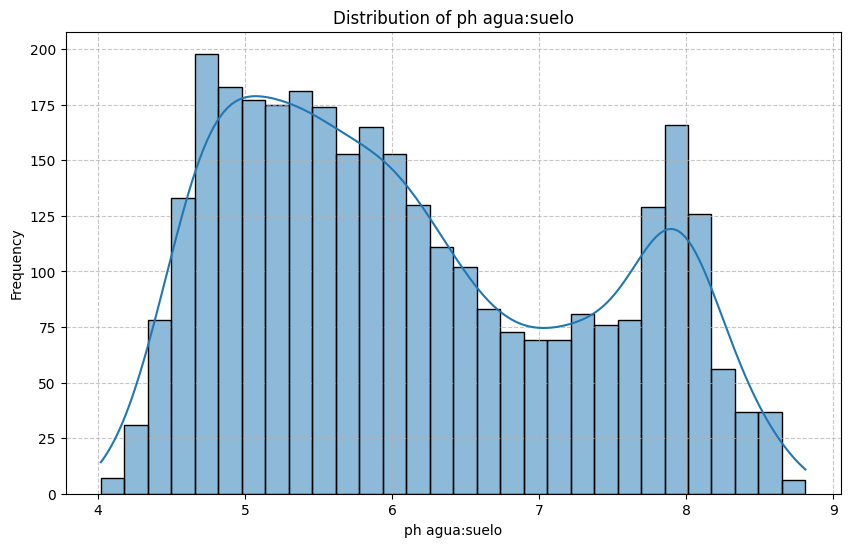

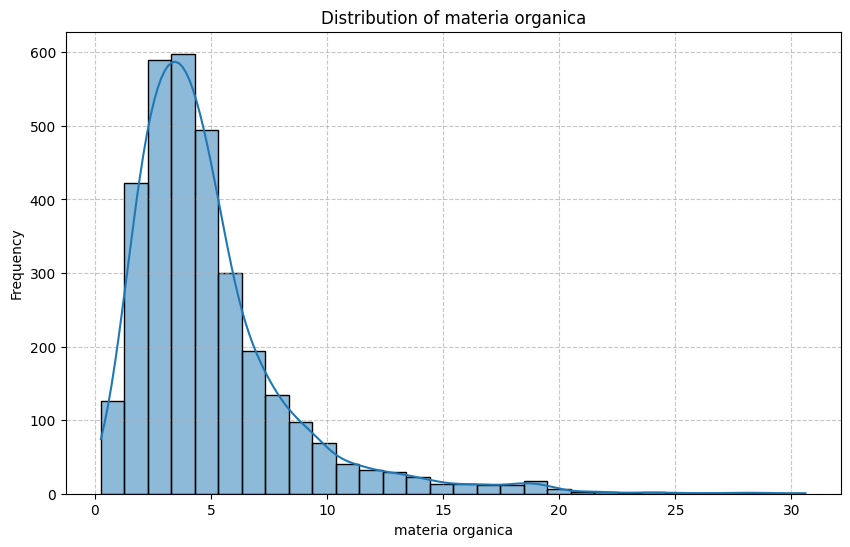

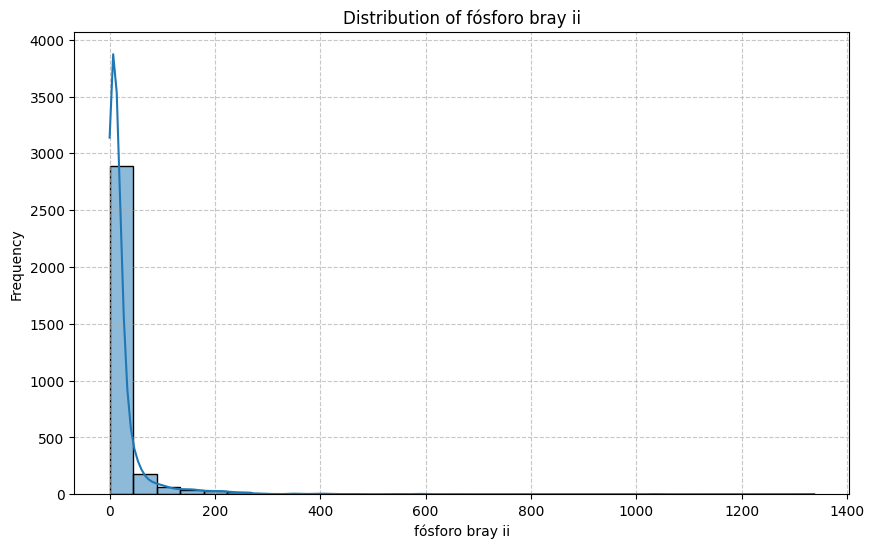

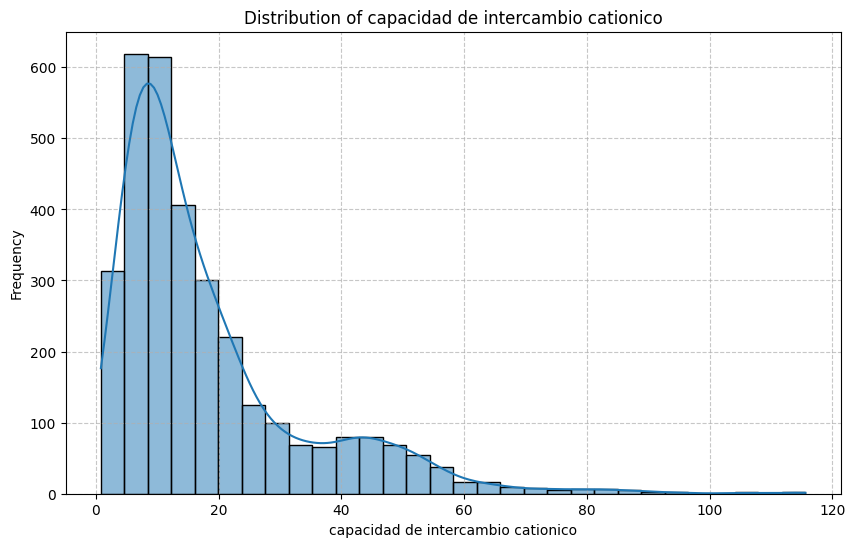

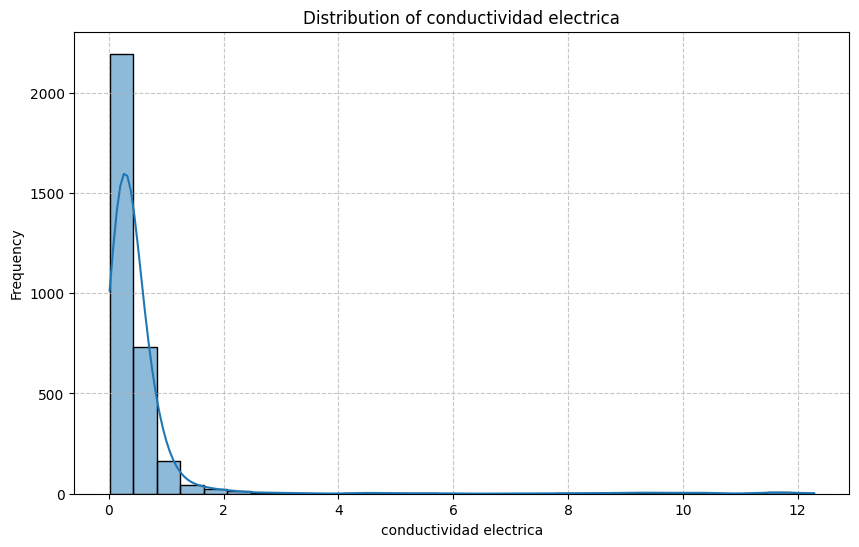

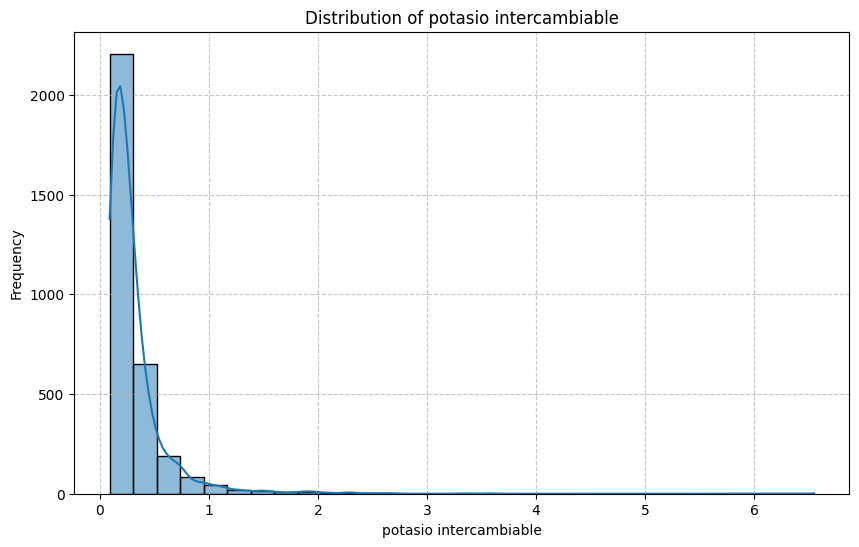

In [ ]:
# Indentificar la distribución de los datos de tipos numpericos
numerical_cols = df_working_copy4.select_dtypes(include=['float64']).columns

print("Generating distribution plots (histograms) for numerical variables...")

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_working_copy4[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

l analizar la distribución de los datos, se observó una fuerte asimetría positiva en algunas variables, especialmente en Fósforo Bray y conductividad eléctrica, las cuales presentan colas largas debido a valores extremadamente altos. Estos valores dificultan la visualización adecuada de la distribución y pueden afectar el proceso de escalado, comprimiendo la mayoría de los datos en rangos muy pequeños.

## Tratamiento de Atípicos

In [ ]:
# Conteo de atípicos
outlier_counts = {}

for col in numerical_cols:
    # elimina atípicos
    series = df_working_copy4[col].dropna()

    # Calcula rango intercuartílico
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # Calcular  IQR)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR

    # Contar atípicos
    num_outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_counts[col] = num_outliers

# Resultados
for col, count in outlier_counts.items():
    print(f"Variable '{col}': {count} outliers")

Variable 'ph agua:suelo': 0 outliers
Variable 'materia organica': 148 outliers
Variable 'fósforo bray ii': 311 outliers
Variable 'capacidad de intercambio cationico': 130 outliers
Variable 'conductividad electrica': 167 outliers
Variable 'potasio intercambiable': 190 outliers


Debido a que los valores atípicos representan más del 10 % del conjunto de datos, no se consideró adecuado eliminarlos, ya que esto reduciría significativamente el tamaño del dataset y podría generar pérdida de información relevante. Por esta razón, se decidió realizar un tratamiento específico sobre las variables más afectadas por valores extremos, con el objetivo de mejorar su distribución sin comprometer la cantidad de datos disponibles.

Para conservar la mayor cantidad de información posible y, al mismo tiempo, reducir el efecto de valores extremadamente altos sobre el escalado y el entrenamiento de los modelos, se aplicó un cappeo utilizando el percentil 97. Este percentil permitió limitar únicamente los valores más extremos de la distribución, manteniendo la variabilidad natural de los datos de suelo y evitando una eliminación excesiva de muestras en un dataset de tamaño reducido.

### Eliminación de Atípicos para 'fósforo bray ii' por percentil 97

In [ ]:
print("Eliminando atípicos para 'fósforo bray ii' superioes al percentil 97...")

# Seleccionar la columna de interés
column_name = 'fósforo bray ii'
series_fosforo = df_working_copy4[column_name].dropna()

# Calcular el percentil 97
p97_fosforo = series_fosforo.quantile(0.95)

# Crear una copia del DataFrame para no modificar el original directamente
df_cleaned_fosforo = df_working_copy4.copy()

# Filtrar el DataFrame para eliminar las filas con atípicos en 'fósforo bray ii'
original_rows = len(df_cleaned_fosforo)
df_cleaned_fosforo = df_cleaned_fosforo[
    df_cleaned_fosforo[column_name] <= p97_fosforo
]

removed_rows = original_rows - len(df_cleaned_fosforo)

print(f"  - Filas eliminadas: {removed_rows}")

# Visualización del df desúés de eliminar atípicos de fósforo
df_cleaned_fosforo.info()


Eliminando atípicos para 'fósforo bray ii' superioes al percentil 97...
  - Filas eliminadas: 162
<class 'pandas.core.frame.DataFrame'>
Index: 3075 entries, 0 to 3257
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   ph agua:suelo                       3075 non-null   float64 
 1   materia organica                    3075 non-null   float64 
 2   fósforo bray ii                     3075 non-null   float64 
 3   capacidad de intercambio cationico  3075 non-null   float64 
 4   conductividad electrica             3075 non-null   float64 
 5   potasio intercambiable              3075 non-null   float64 
 6   departamento_encoded                3075 non-null   category
 7   municipio_encoded                   3075 non-null   category
 8   tiempo_establecimiento_encoded      3075 non-null   category
 9   topografia_encoded                  3075 non-null   category
 10  rie

### Eliminación de Atípicos para 'conductividad electrica' por percentil 97

In [ ]:
# Seleccionar la columna de interés
column_name_ce = 'conductividad electrica'
series_ce = df_cleaned_fosforo[column_name_ce].dropna()

# Calcular el percentil 97
p97_ce = series_ce.quantile(0.97)

# Filtrar el DataFrame para eliminar las filas con atípicos en 'conductividad electrica'
original_rows_ce = len(df_cleaned_fosforo)
df_cleaned_fosforo = df_cleaned_fosforo[
    df_cleaned_fosforo[column_name_ce] <= p97_ce
]

removed_rows_ce = original_rows_ce - len(df_cleaned_fosforo)

print(f"  - Filas eliminadas: {removed_rows_ce}")

print("\nInformación del DataFrame después de eliminar atípicos de 'conductividad electrica':")
df_cleaned_fosforo.info()


  - Filas eliminadas: 93

Información del DataFrame después de eliminar atípicos de 'conductividad electrica':
<class 'pandas.core.frame.DataFrame'>
Index: 2982 entries, 1 to 3257
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   ph agua:suelo                       2982 non-null   float64 
 1   materia organica                    2982 non-null   float64 
 2   fósforo bray ii                     2982 non-null   float64 
 3   capacidad de intercambio cationico  2982 non-null   float64 
 4   conductividad electrica             2982 non-null   float64 
 5   potasio intercambiable              2982 non-null   float64 
 6   departamento_encoded                2982 non-null   category
 7   municipio_encoded                   2982 non-null   category
 8   tiempo_establecimiento_encoded      2982 non-null   category
 9   topografia_encoded                  2982 non-null   cate

Para las demás variables, y con el fin de reducir la pérdida de información, los valores atípicos superiores al percentil 99 fueron reemplazados por el valor correspondiente a dicho percentil.

In [ ]:
df_capped = df_cleaned_fosforo.copy() # Create a copy to store capped values

for col in numerical_cols:
    # Calcular percentil 99
    p99 = df_capped[col].quantile(0.99)

    # Valores de este percentil
    original_max = df_capped[col].max()
    df_capped[col] = df_capped[col].apply(lambda x: p99 if x > p99 else x)
    capped_max = df_capped[col].max()
    print(f"  - Variable '{col}': 99th percentile is {p99:.2f}. Original max: {original_max:.2f}, New max: {capped_max:.2f}.")


  - Variable 'ph agua:suelo': 99th percentile is 8.54. Original max: 8.81, New max: 8.54.
  - Variable 'materia organica': 99th percentile is 18.65. Original max: 30.60, New max: 18.65.
  - Variable 'fósforo bray ii': 99th percentile is 78.48. Original max: 92.73, New max: 78.48.
  - Variable 'capacidad de intercambio cationico': 99th percentile is 58.44. Original max: 85.77, New max: 58.44.
  - Variable 'conductividad electrica': 99th percentile is 1.34. Original max: 1.72, New max: 1.34.
  - Variable 'potasio intercambiable': 99th percentile is 1.37. Original max: 6.55, New max: 1.37.


### Visualización depués de tratar atípicos

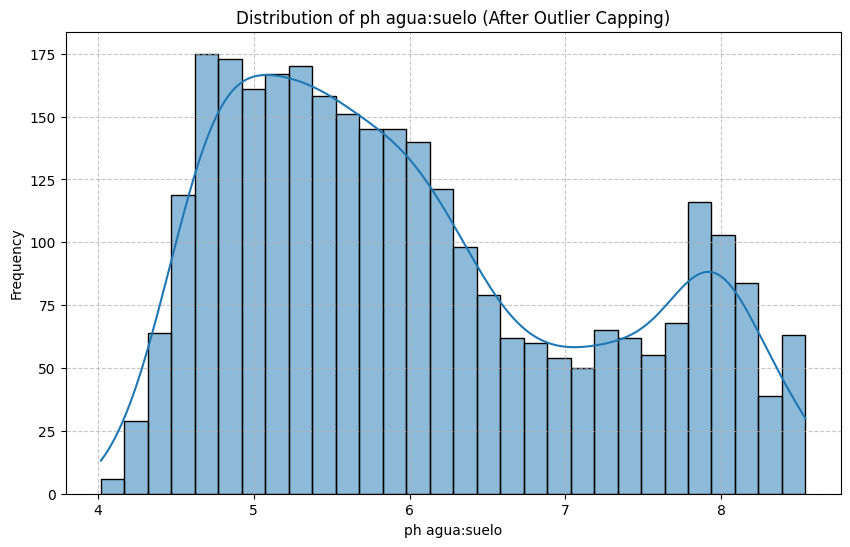

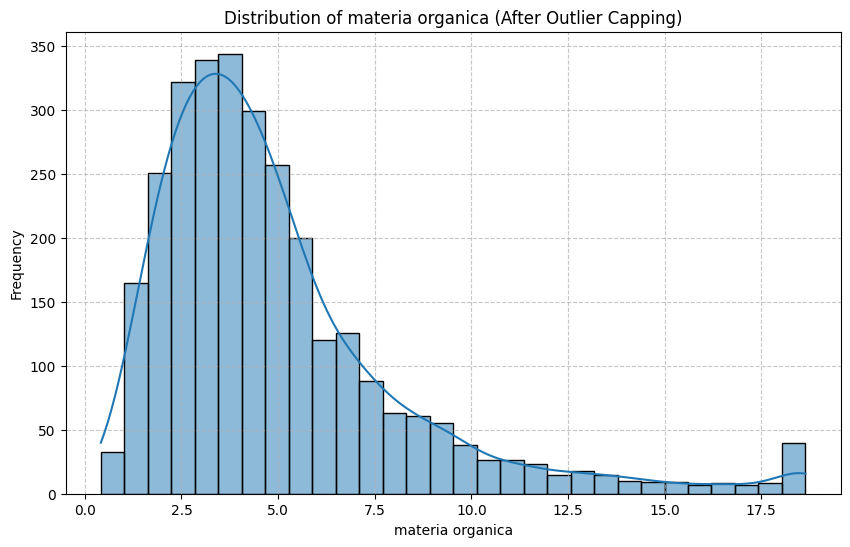

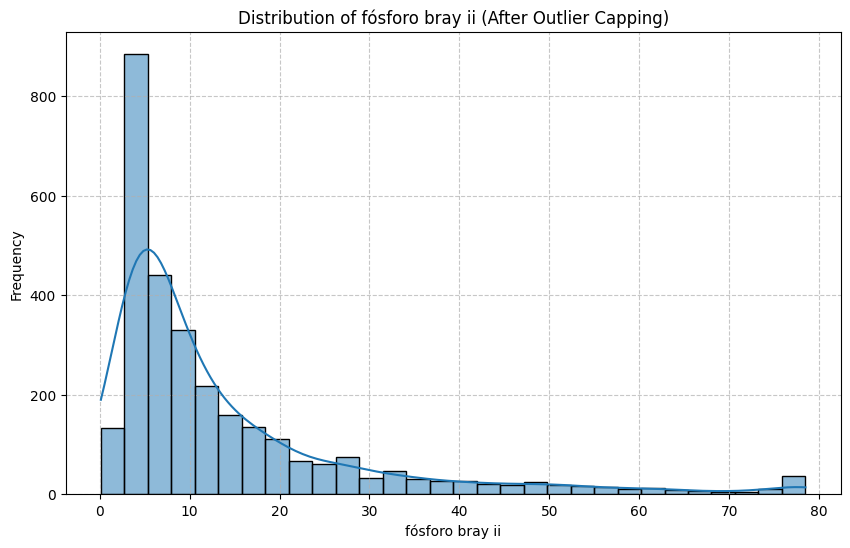

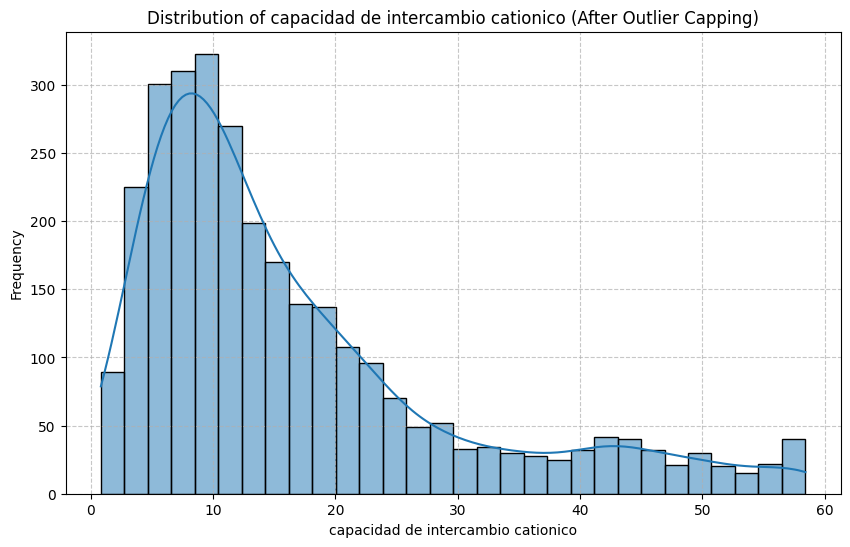

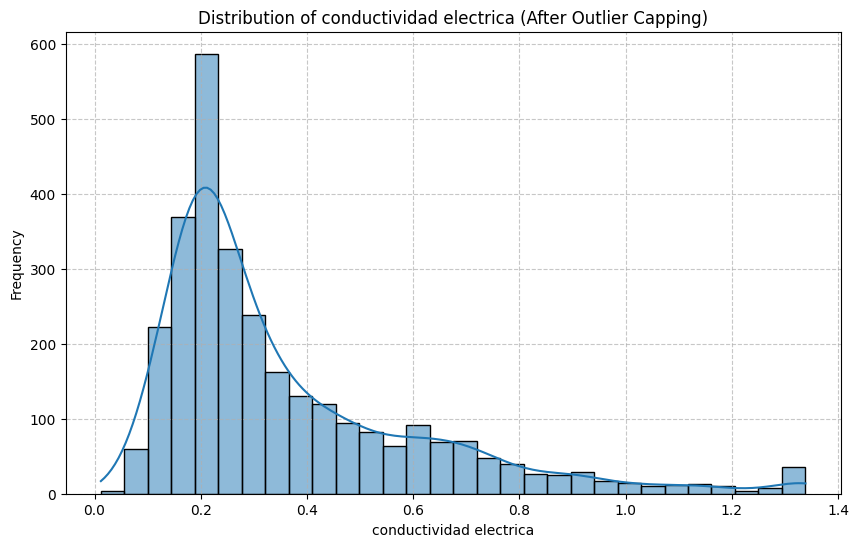

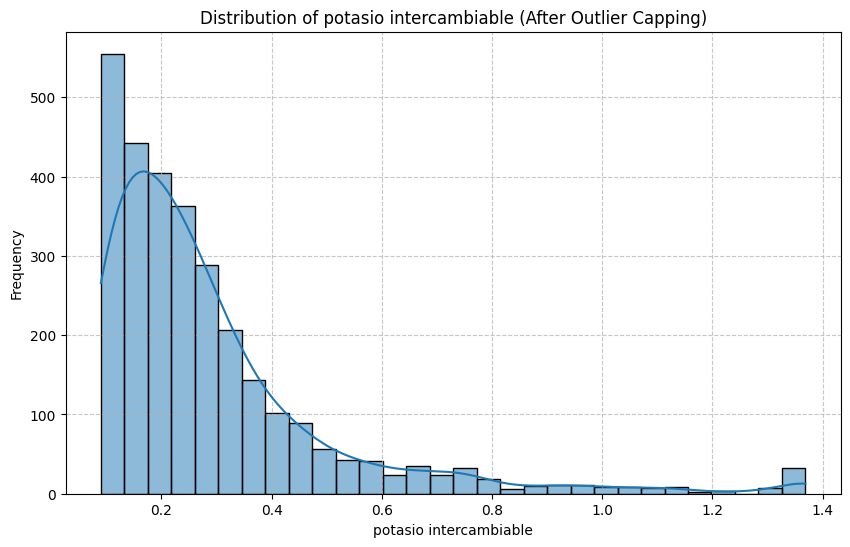

In [ ]:
numerical_cols = df_capped.select_dtypes(include=['float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_capped[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col} (After Outlier Capping)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Después del tratamiento de los valores atípicos, la distribución de los datos presenta una mejor visualización, reduciendo las colas extremas y disminuyendo posibles sesgos durante el entrenamiento de los modelos.

# Adaptación a clasificación
Después de diferentes ensayos, se decidió realizar una clasificación en tres niveles del elemento químico del suelo. Inicialmente, se planteó utilizar rangos ideales agronómicos para la planta; sin embargo, para mejorar el balance entre clases y facilitar el entrenamiento de los modelos, las categorías se definieron utilizando percentiles, obteniendo así tres clases con una distribución más equilibrada de los datos.

## Fósforo Bray

In [ ]:
# Seleccionar la columna de interés
phosphorus_series = df_cleaned_fosforo['fósforo bray ii'].dropna()

# Calcular los terciles solicitados
p33_phosphorus = phosphorus_series.quantile(0.33)
p66_phosphorus = phosphorus_series.quantile(0.66)

print(f"  - Percentil 33 para 'fósforo bray ii': {p33_phosphorus:.2f}")
print(f"  - Percentil 66 para 'fósforo bray ii': {p66_phosphorus:.2f}")

  - Percentil 33 para 'fósforo bray ii': 5.22
  - Percentil 66 para 'fósforo bray ii': 12.67


In [ ]:
# Definir rangos para las clases
def clasificar_fosforo_terciles(valor):
    if valor <= p33_phosphorus:
        return 0  # Bajo
    elif valor <= p66_phosphorus:
        return 1  # Medio
    else:
        return 2  # Alto

# Aplicar la función actualizada a la columna 'fósforo bray ii' y crear la nueva columna categórica
df_cleaned_fosforo['fosforo_category'] = df_cleaned_fosforo['fósforo bray ii'].apply(clasificar_fosforo_terciles)

# Convertir la nueva columna a tipo 'category'
df_cleaned_fosforo['fosforo_category'] = df_cleaned_fosforo['fosforo_category'].astype('category')

print("\nInformación del DataFrame con la nueva columna categórica actualizada:")
df_cleaned_fosforo.info()

print("\nDistribución de las nuevas categorías de 'fosforo_category':")
display(df_cleaned_fosforo['fosforo_category'].value_counts())


Información del DataFrame con la nueva columna categórica actualizada:
<class 'pandas.core.frame.DataFrame'>
Index: 2982 entries, 1 to 3257
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   ph agua:suelo                       2982 non-null   float64 
 1   materia organica                    2982 non-null   float64 
 2   fósforo bray ii                     2982 non-null   float64 
 3   capacidad de intercambio cationico  2982 non-null   float64 
 4   conductividad electrica             2982 non-null   float64 
 5   potasio intercambiable              2982 non-null   float64 
 6   departamento_encoded                2982 non-null   category
 7   municipio_encoded                   2982 non-null   category
 8   tiempo_establecimiento_encoded      2982 non-null   category
 9   topografia_encoded                  2982 non-null   category
 10  riego_encoded                

,count
fosforo_category,
2,1014
0,984
1,984


In [ ]:
# Eliminar columnas no necesarias o representativas
# 'fósforo bray ii' se elimina porque es la base de la variable objetivo 'fosforo_category'
df_cleaned_fosforo = df_cleaned_fosforo.drop(columns=['fósforo bray ii'], errors='ignore')

# Las siguientes columnas fueron eliminadas para reducir dimensionalidad y seleccionar un subconjunto específico de características.
# Esto resultó en el conjunto de 14 características utilizado en los modelos iniciales.
df_cleaned_fosforo = df_cleaned_fosforo.drop(columns=[
    'riego_encoded',
    'departamento_encoded'
], errors='ignore')

### División de Datos en Conjuntos de Entrenamiento y Prueba

In [ ]:
from sklearn.model_selection import train_test_split

# Definir las variables objetivo (y)
y_fosforo_category = df_cleaned_fosforo['fosforo_category']

# Definir las características (X) eliminando las variables objetivo
X = df_cleaned_fosforo.drop(columns=['fosforo_category'])

print("Dividiendo el dataset para el modelo de 'fosforo_category' (80/20 split)...")
X_train_fosforo, X_test_fosforo, y_train_fosforo_category, y_test_fosforo_category = train_test_split(X, y_fosforo_category, test_size=0.2, random_state=42, stratify=y_fosforo_category) # stratify for classification target

print(f"entrenamiento de características (fósforo): {X_train_fosforo.shape}")
print(f"prueba de características (fósforo): {X_test_fosforo.shape}")


Dividiendo el dataset para el modelo de 'fosforo_category' (80/20 split)...
entrenamiento de características (fósforo): (2385, 15)
prueba de características (fósforo): (597, 15)


### Escalado de Características para Fósforo Bray (RobustScaler)

In [ ]:
from sklearn.preprocessing import RobustScaler

# Identificar columnas numéricas y categóricas
numerical_cols_fosforo = X_train_fosforo.select_dtypes(include=['float64']).columns
categorical_cols_fosforo = X_train_fosforo.select_dtypes(include=['category']).columns

# Inicializar RobustScaler
r_scaler_fosforo = RobustScaler()

# Ajustar el scaler a los datos de entrenamiento numéricos y transformar
X_train_fosforo_numerical_scaled = r_scaler_fosforo.fit_transform(X_train_fosforo[numerical_cols_fosforo])

# Transformar los datos de prueba numéricos usando el scaler ajustado
X_test_fosforo_numerical_scaled = r_scaler_fosforo.transform(X_test_fosforo[numerical_cols_fosforo])

# Convertir arrays escalados de vuelta a DataFrames con sus índices y nombres de columnas originales
X_train_fosforo_numerical_scaled_df = pd.DataFrame(X_train_fosforo_numerical_scaled, columns=numerical_cols_fosforo, index=X_train_fosforo.index)
X_test_fosforo_numerical_scaled_df = pd.DataFrame(X_test_fosforo_numerical_scaled, columns=numerical_cols_fosforo, index=X_test_fosforo.index)

# Combinar características numéricas escaladas con características categóricas originales
X_train_fosforo_scaled = pd.concat([X_train_fosforo_numerical_scaled_df, X_train_fosforo[categorical_cols_fosforo]], axis=1)
X_test_fosforo_scaled = pd.concat([X_test_fosforo_numerical_scaled_df, X_test_fosforo[categorical_cols_fosforo]], axis=1)


### Pca

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Obtener las columnas numéricas escaladas que se usarán para PCA
# Ya están disponibles como X_train_fosforo_numerical_scaled_df y X_test_fosforo_numerical_scaled_df

# Inicializar PCA. Mantener el 95% de la varianza explicada.
pca_fosforo = PCA(n_components=0.95, random_state=42)

# Ajustar PCA solo en el conjunto de entrenamiento numérico escalado
pca_fosforo.fit(X_train_fosforo_numerical_scaled_df)

# Transformar tanto el conjunto de entrenamiento como el de prueba numérico escalado
X_train_fosforo_numerical_pca = pca_fosforo.transform(X_train_fosforo_numerical_scaled_df)
X_test_fosforo_numerical_pca = pca_fosforo.transform(X_test_fosforo_numerical_scaled_df)

print(f"Número de componentes principales seleccionados: {pca_fosforo.n_components_}")
print(f"Varianza explicada acumulada: {np.sum(pca_fosforo.explained_variance_ratio_):.4f}")

# Crear DataFrames para las componentes PCA
pca_columns = [f'PC_{i+1}' for i in range(pca_fosforo.n_components_)]
X_train_fosforo_pca_df = pd.DataFrame(X_train_fosforo_numerical_pca, columns=pca_columns, index=X_train_fosforo_numerical_scaled_df.index)
X_test_fosforo_pca_df = pd.DataFrame(X_test_fosforo_numerical_pca, columns=pca_columns, index=X_test_fosforo_numerical_scaled_df.index)

# Concatenar las componentes PCA con las características categóricas originales
categorical_cols_fosforo = X_train_fosforo.select_dtypes(include=['category']).columns
X_train_fosforo_pca_final = pd.concat([X_train_fosforo_pca_df, X_train_fosforo[categorical_cols_fosforo]], axis=1)
X_test_fosforo_pca_final = pd.concat([X_test_fosforo_pca_df, X_test_fosforo[categorical_cols_fosforo]], axis=1)

print("Dimensiones del conjunto de entrenamiento después de PCA y concatenación:", X_train_fosforo_pca_final.shape)
print("Dimensiones del conjunto de prueba después de PCA y concatenación:", X_test_fosforo_pca_final.shape)

display(X_train_fosforo_pca_final.head())

Número de componentes principales seleccionados: 4
Varianza explicada acumulada: 0.9761
Dimensiones del conjunto de entrenamiento después de PCA y concatenación: (2385, 14)
Dimensiones del conjunto de prueba después de PCA y concatenación: (597, 14)


,PC_1,PC_2,PC_3,PC_4,municipio_encoded,tiempo_establecimiento_encoded,topografia_encoded,drenaje_encoded,aplica_p,aplica_k,aplica_cal,aplica_organico,aplica_kcl,fert_generica
2862,0.710305,0.415041,-0.928103,0.051297,9,0,1,1,0,0,0,0,0,0
942,-1.576221,-0.936893,-0.730214,0.292269,111,0,5,0,0,0,0,0,0,0
1468,-0.370397,2.580878,-0.014351,-0.907393,138,4,5,3,0,0,0,1,0,0
3053,1.626140,2.039377,-0.794698,-0.911478,48,1,1,3,0,0,0,0,0,1
2707,-0.736135,-0.565983,0.969064,0.568653,62,4,2,3,0,0,0,0,0,0


Generando Pair Plot para los Componentes Principales...


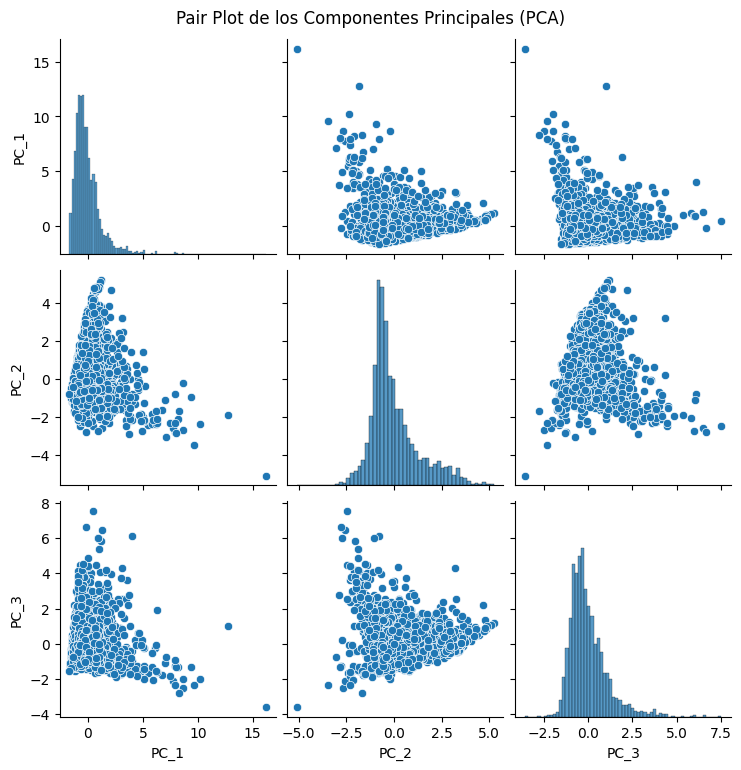

Pair Plot de los Componentes Principales generado exitosamente.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando Pair Plot para los Componentes Principales...")

# Seleccionar solo las columnas PCA para el pairplot
pca_cols = ['PC_1', 'PC_2', 'PC_3']
pair_plot_fig = sns.pairplot(X_train_fosforo_pca_final[pca_cols])
plt.suptitle('Pair Plot de los Componentes Principales (PCA)', y=1.02) # Ajusta la altura del título
plt.show()

print("Pair Plot de los Componentes Principales generado exitosamente.")

Generando Pair Plot para las características numéricas escaladas (Sin PCA) coloreado por 'fosforo_category'...


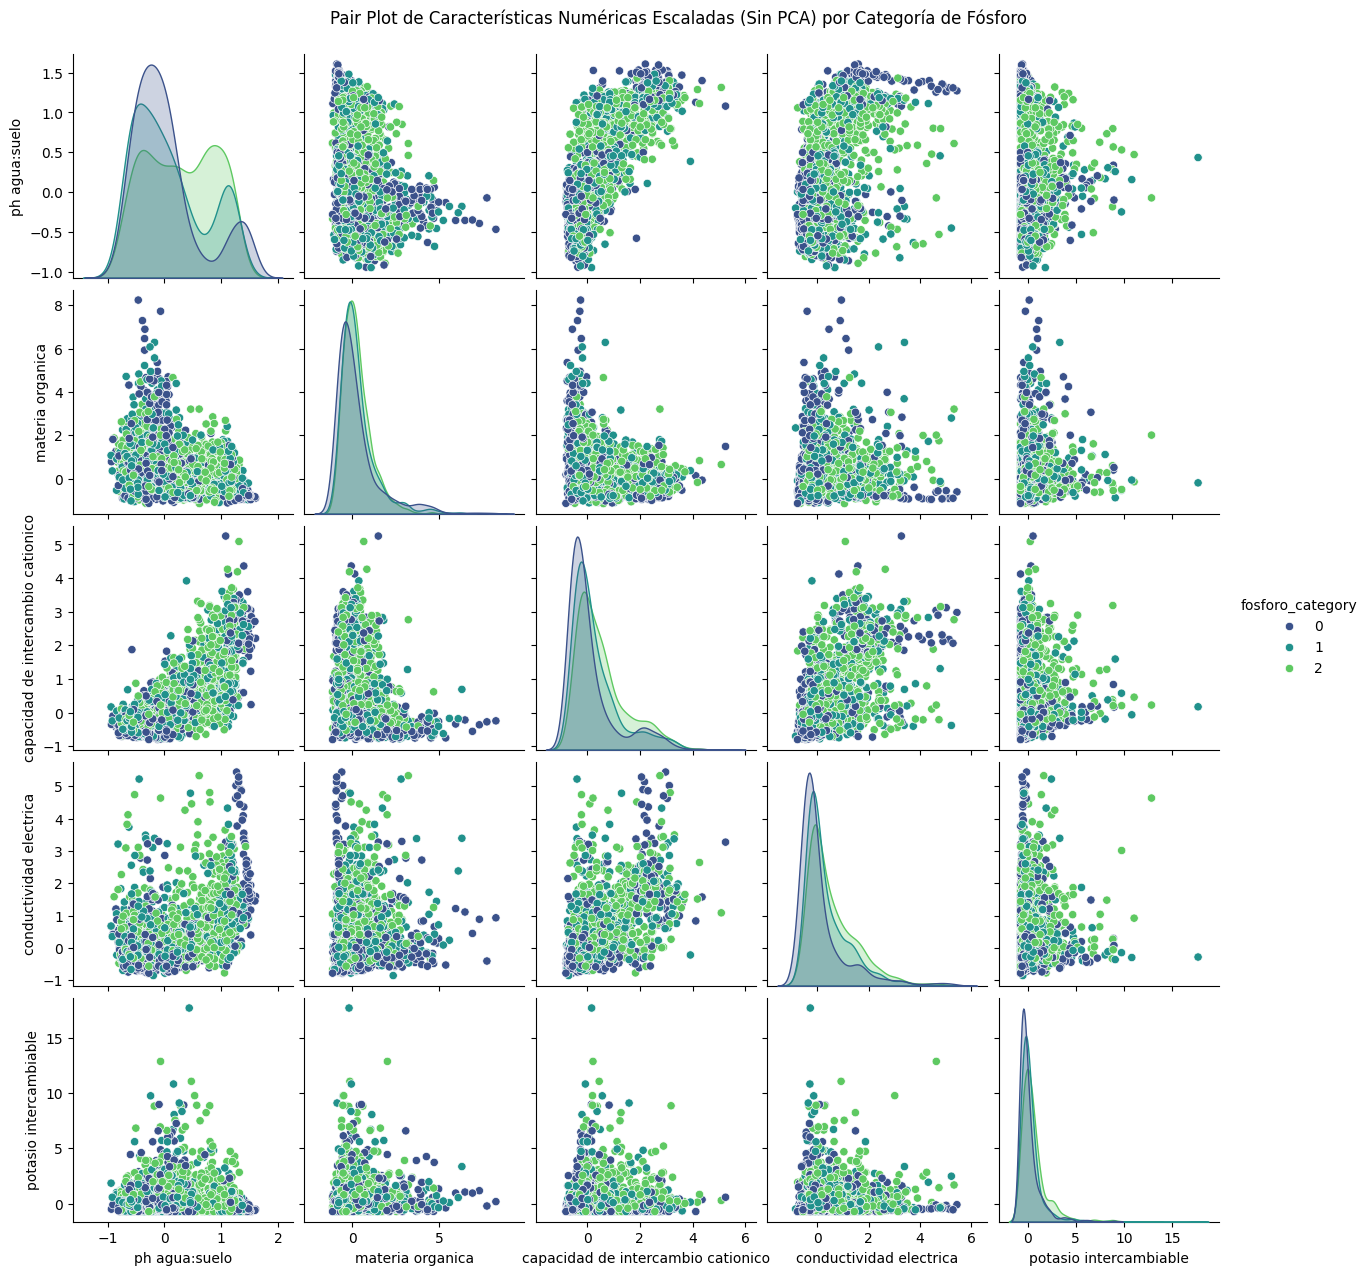

Pair Plot de características numéricas escaladas coloreado por 'fosforo_category' generado exitosamente.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando Pair Plot para las características numéricas escaladas (Sin PCA) coloreado por 'fosforo_category'...")

# Seleccionar solo las columnas numéricas escaladas de X_train_fosforo_scaled
numerical_cols_scaled = X_train_fosforo_scaled.select_dtypes(include=['float64']).columns

# Incluir la columna de categoría para el 'hue'
df_for_pairplot = pd.concat([X_train_fosforo_scaled[numerical_cols_scaled], y_train_fosforo_category], axis=1)

pair_plot_fig_no_pca = sns.pairplot(df_for_pairplot, hue='fosforo_category', palette='viridis')
plt.suptitle('Pair Plot de Características Numéricas Escaladas (Sin PCA) por Categoría de Fósforo', y=1.02) # Ajusta la altura del título
plt.show()

print("Pair Plot de características numéricas escaladas coloreado por 'fosforo_category' generado exitosamente.")

Los datos tienen poca separabilidad, son muy similares entre clases

# Modelos

## Random forest

Se seleccionó el modelo Random Forest debido a su capacidad para manejar relaciones no lineales y datos heterogéneos, características comunes en variables de suelo y manejo agronómico. Además, este modelo es robusto frente a valores atípicos, permite trabajar con variables numéricas y categóricas, y reduce el riesgo de sobreajuste mediante el uso de múltiples árboles de decisión.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Creando y entrenando el modelo RandomForestClassifier para 'fosforo_category'...")

# 7. Crear el modelo
modelo_fosforo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# 8. Entrenar el modelo
modelo_fosforo_rf.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("Modelo RandomForestClassifier entrenado.")

# 9. Realizar predicciones en el conjunto de prueba
y_pred_fosforo_category = modelo_fosforo_rf.predict(X_test_fosforo_scaled)

# 10. Evaluar el rendimiento del modelo
accuracy_fosforo = accuracy_score(y_test_fosforo_category, y_pred_fosforo_category)
report_fosforo = classification_report(y_test_fosforo_category, y_pred_fosforo_category)

print(f"\nAccuracy para 'fosforo_category': {accuracy_fosforo:.4f}")
print("\nClassification Report para 'fosforo_category':\n")
print(report_fosforo)

Creando y entrenando el modelo RandomForestClassifier para 'fosforo_category'...
Modelo RandomForestClassifier entrenado.

Accuracy para 'fosforo_category': 0.5394

Classification Report para 'fosforo_category':

              precision    recall  f1-score   support

           0       0.60      0.62      0.61       197
           1       0.43      0.38      0.40       197
           2       0.57      0.62      0.59       203

    accuracy                           0.54       597
   macro avg       0.53      0.54      0.53       597
weighted avg       0.53      0.54      0.54       597



Generando la matriz de confusión para el primer modelo RandomForest de 'fosforo_category'...


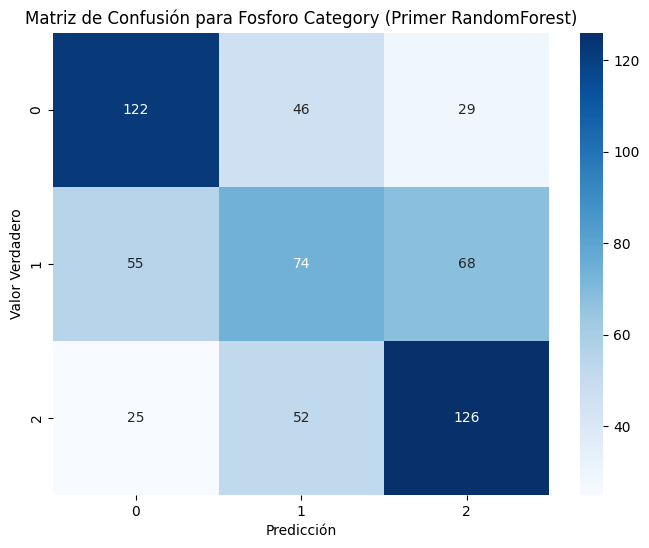

Matriz de confusión para el primer modelo RandomForest de 'fosforo_category' generada exitosamente.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generando la matriz de confusión para el primer modelo RandomForest de 'fosforo_category'...")

# Calcular la matriz de confusión
cm_rf_fosforo_first = confusion_matrix(y_test_fosforo_category, y_pred_fosforo_category)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_fosforo_first, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (Primer RandomForest)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para el primer modelo RandomForest de 'fosforo_category' generada exitosamente.")

### Random Forest con PCA

Creando y entrenando el modelo RandomForestClassifier para 'fosforo_category' con características PCA...
Modelo RandomForestClassifier con PCA entrenado.

Accuracy para 'fosforo_category' (RF con PCA): 0.5276

Classification Report para 'fosforo_category' (RF con PCA):

              precision    recall  f1-score   support

           0       0.57      0.61      0.59       197
           1       0.45      0.33      0.38       197
           2       0.54      0.64      0.59       203

    accuracy                           0.53       597
   macro avg       0.52      0.53      0.52       597
weighted avg       0.52      0.53      0.52       597


Generando la matriz de confusión para 'fosforo_category' (RF con PCA)...


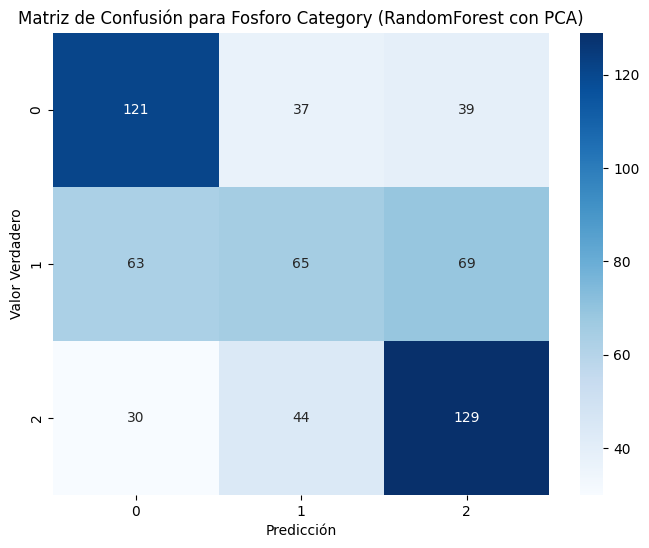

Matriz de confusión para 'fosforo_category' (RF con PCA) generada exitosamente.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Creando y entrenando el modelo RandomForestClassifier para 'fosforo_category' con características PCA...")

# 7. Crear el modelo (usando los mismos hiperparámetros que el primer RF para comparación)
modelo_fosforo_rf_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# 8. Entrenar el modelo con las características PCA
modelo_fosforo_rf_pca.fit(X_train_fosforo_pca_final, y_train_fosforo_category)

print("Modelo RandomForestClassifier con PCA entrenado.")

# 9. Realizar predicciones en el conjunto de prueba con características PCA
y_pred_fosforo_category_pca = modelo_fosforo_rf_pca.predict(X_test_fosforo_pca_final)

# 10. Evaluar el rendimiento del modelo
accuracy_fosforo_pca = accuracy_score(y_test_fosforo_category, y_pred_fosforo_category_pca)
report_fosforo_pca = classification_report(y_test_fosforo_category, y_pred_fosforo_category_pca)

print(f"\nAccuracy para 'fosforo_category' (RF con PCA): {accuracy_fosforo_pca:.4f}")
print("\nClassification Report para 'fosforo_category' (RF con PCA):\n")
print(report_fosforo_pca)

print("\nGenerando la matriz de confusión para 'fosforo_category' (RF con PCA)...")

# Calcular la matriz de confusión
cm_rf_fosforo_pca = confusion_matrix(y_test_fosforo_category, y_pred_fosforo_category_pca)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_fosforo_pca, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (RandomForest con PCA)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para 'fosforo_category' (RF con PCA) generada exitosamente.")

### Optimización de Hiperparámetros para Fósforo (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd # Import pandas for DataFrame creation

print("Realizando la búsqueda de hiperparámetros con GridSearchCV para 'fosforo_category'...")

# Definir el modelo base
rf_model_grid = RandomForestClassifier(random_state=42, n_jobs=-1)

# Definir la cuadrícula de hiperparámetros a buscar
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [10, 15, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Configurar GridSearchCV
grid_search_fosforo = GridSearchCV(
    estimator=rf_model_grid,
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    scoring='accuracy', # Use accuracy as the scoring metric
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Ejecutar la búsqueda en el conjunto de entrenamiento escalado
grid_search_fosforo.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("\nBúsqueda de hiperparámetros completada.")

# Mostrar los mejores parámetros y la mejor puntuación
print(f"Mejores hiperparámetros encontrados: {grid_search_fosforo.best_params_}")
print(f"Mejor puntuación (accuracy) en validación cruzada: {grid_search_fosforo.best_score_:.4f}")

# Obtener el mejor modelo
best_rf_model_fosforo = grid_search_fosforo.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_best_fosforo = best_rf_model_fosforo.predict(X_test_fosforo_scaled)

# Imprimir el classification report del mejor modelo
from sklearn.metrics import classification_report
print("\nClassification Report del mejor modelo RandomForestClassifier para 'fosforo_category':\n")
print(classification_report(y_test_fosforo_category, y_pred_best_fosforo))

# Obtener las importancias de las características del mejor modelo
feature_importances = best_rf_model_fosforo.feature_importances_

# Obtener los nombres de las características
feature_names = X_train_fosforo_scaled.columns

# Crear un DataFrame para visualizar las importancias
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nVariables más importantes para la predicción de 'fosforo_category':")
display(importance_df)


Realizando la búsqueda de hiperparámetros con GridSearchCV para 'fosforo_category'...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Búsqueda de hiperparámetros completada.
Mejores hiperparámetros encontrados: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor puntuación (accuracy) en validación cruzada: 0.5820

Classification Report del mejor modelo RandomForestClassifier para 'fosforo_category':

              precision    recall  f1-score   support

           0       0.61      0.61      0.61       197
           1       0.43      0.39      0.41       197
           2       0.57      0.62      0.60       203

    accuracy                           0.54       597
   macro avg       0.54      0.54      0.54       597
weighted avg       0.54      0.54      0.54       597


Variables más importantes para la predicción de 'fosforo_category':


,Feature,Importance
3,conductividad electrica,0.156934
0,ph agua:suelo,0.154953
2,capacidad de intercambio cationico,0.144629
4,potasio intercambiable,0.132129
1,materia organica,0.131127
5,municipio_encoded,0.109968
7,topografia_encoded,0.044938
6,tiempo_establecimiento_encoded,0.042385
8,drenaje_encoded,0.034742
14,fert_generica,0.013989


### Matriz de Confusión para 'fosforo_category'

Generando la matriz de confusión para 'fosforo_category'...


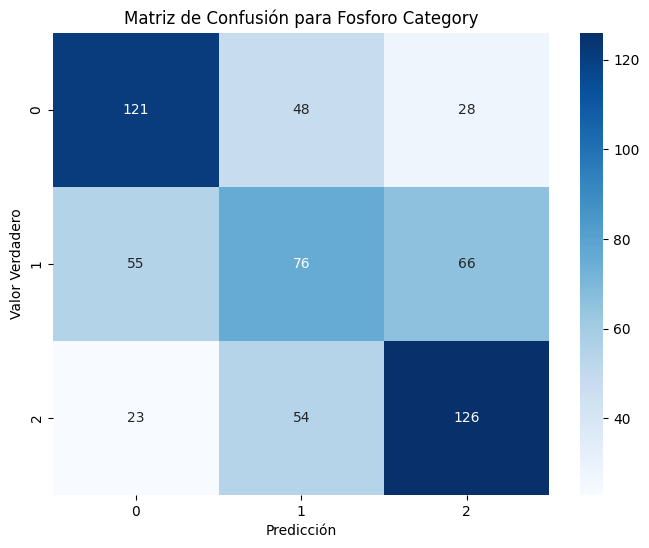

Matriz de confusión generada exitosamente.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generando la matriz de confusión para 'fosforo_category'...")

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_fosforo_category, y_pred_best_fosforo)

# Obtener las etiquetas de las clases
class_labels = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión para Fosforo Category')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión generada exitosamente.")

## SVM

Creando y entrenando el modelo SVC para 'fosforo_category'...
Modelo SVC entrenado.

Accuracy para 'fosforo_category' (SVC): 0.5226

Classification Report para 'fosforo_category' (SVC):

              precision    recall  f1-score   support

           0       0.58      0.60      0.59       197
           1       0.42      0.41      0.42       197
           2       0.56      0.56      0.56       203

    accuracy                           0.52       597
   macro avg       0.52      0.52      0.52       597
weighted avg       0.52      0.52      0.52       597


Generando la matriz de confusión para 'fosforo_category' (SVC)...


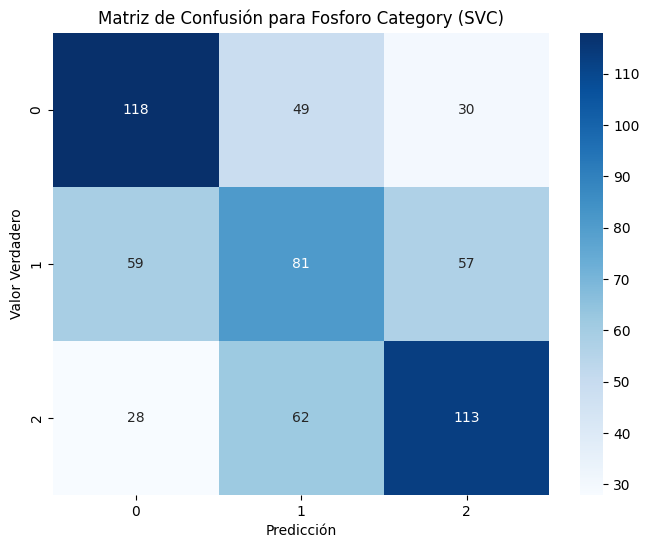

Matriz de confusión para 'fosforo_category' (SVC) generada exitosamente.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Creando y entrenando el modelo SVC para 'fosforo_category'...")

# Definir el pipeline del modelo SVC
modelo_svc_fosforo = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Add imputer to handle NaNs (even if already handled, for robustness)
    ('scaler', RobustScaler()), # Scaler is already applied to X_train_fosforo_scaled, but keeping in pipeline for consistency
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

# Entrenar el modelo con los datos escalados de fósforo
# Note: X_train_fosforo_scaled already has numerical features scaled and categorical features concatenated.
# The RobustScaler in the pipeline will operate on the numerical columns it finds,
# and SimpleImputer is mostly a safeguard here as NaNs should be gone.
modelo_svc_fosforo.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("Modelo SVC entrenado.")

# Realizar predicciones en el conjunto de prueba escalado
y_pred_svc_fosforo = modelo_svc_fosforo.predict(X_test_fosforo_scaled)

# Evaluar el rendimiento del modelo
accuracy_svc_fosforo = accuracy_score(y_test_fosforo_category, y_pred_svc_fosforo)
report_svc_fosforo = classification_report(y_test_fosforo_category, y_pred_svc_fosforo)

print(f"\nAccuracy para 'fosforo_category' (SVC): {accuracy_svc_fosforo:.4f}")
print("\nClassification Report para 'fosforo_category' (SVC):\n")
print(report_svc_fosforo)

print("\nGenerando la matriz de confusión para 'fosforo_category' (SVC)...")

# Calcular la matriz de confusión
cm_svc_fosforo = confusion_matrix(y_test_fosforo_category, y_pred_svc_fosforo)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc_fosforo, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (SVC)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para 'fosforo_category' (SVC) generada exitosamente.")

### Optimización de Hiperparámetros para Fósforo (SVC con GridSearchCV)

Realizando la búsqueda de hiperparámetros con GridSearchCV para SVC de 'fosforo_category'...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Búsqueda de hiperparámetros completada.
Mejores hiperparámetros encontrados: {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Mejor puntuación (accuracy) en validación cruzada: 0.5354

Classification Report del mejor modelo SVC para 'fosforo_category':

              precision    recall  f1-score   support

           0       0.53      0.58      0.55       197
           1       0.38      0.32      0.35       197
           2       0.54      0.58      0.56       203

    accuracy                           0.49       597
   macro avg       0.48      0.49      0.49       597
weighted avg       0.48      0.49      0.49       597


Generando la matriz de confusión para el mejor modelo SVC de 'fosforo_category'...


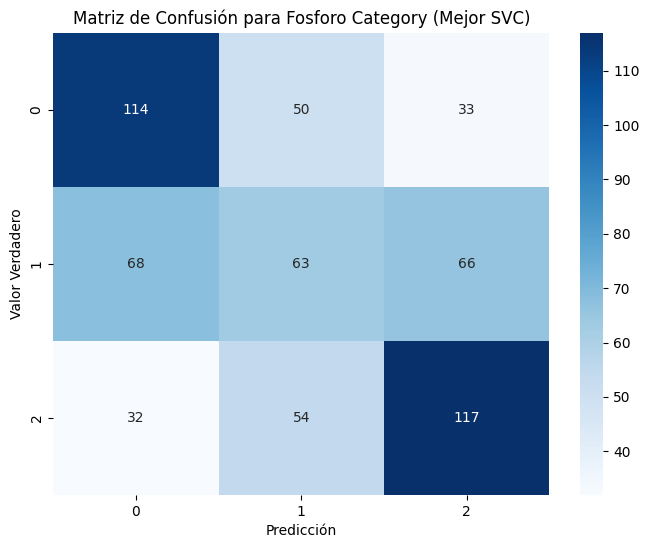

Matriz de confusión para el mejor modelo SVC de 'fosforo_category' generada exitosamente.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

print("Realizando la búsqueda de hiperparámetros con GridSearchCV para SVC de 'fosforo_category'...")

# Definir el pipeline del modelo SVC (similar al anterior, pero para GridSearchCV)
svc_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('svc', SVC(random_state=42))
])

# Definir la cuadrícula de hiperparámetros a buscar para el SVC
param_grid_svc = {
    'svc__C': [0.1, 1, 10, 100], # Regularization parameter
    'svc__gamma': ['scale', 'auto', 0.1, 1, 10], # Kernel coefficient
    'svc__kernel': ['rbf', 'linear'] # Type of kernel
}

# Configurar GridSearchCV
grid_search_svc_fosforo = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid_svc,
    cv=3, # 3-fold cross-validation
    scoring='accuracy', # Use accuracy as the scoring metric
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Ejecutar la búsqueda en el conjunto de entrenamiento escalado
grid_search_svc_fosforo.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("\nBúsqueda de hiperparámetros completada.")

# Mostrar los mejores parámetros y la mejor puntuación
print(f"Mejores hiperparámetros encontrados: {grid_search_svc_fosforo.best_params_}")
print(f"Mejor puntuación (accuracy) en validación cruzada: {grid_search_svc_fosforo.best_score_:.4f}")

# Obtener el mejor modelo
best_svc_model_fosforo = grid_search_svc_fosforo.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_best_svc_fosforo = best_svc_model_fosforo.predict(X_test_fosforo_scaled)

# Imprimir el classification report del mejor modelo
print("\nClassification Report del mejor modelo SVC para 'fosforo_category':\n")
print(classification_report(y_test_fosforo_category, y_pred_best_svc_fosforo))

# Generar la matriz de confusión para el mejor modelo SVC
print("\nGenerando la matriz de confusión para el mejor modelo SVC de 'fosforo_category'...")
cm_best_svc_fosforo = confusion_matrix(y_test_fosforo_category, y_pred_best_svc_fosforo)
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svc_fosforo, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (Mejor SVC)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()
print("Matriz de confusión para el mejor modelo SVC de 'fosforo_category' generada exitosamente.")

## Modelo de Clasificación para Fósforo (XGBoostClassifier)

Creando y entrenando el modelo XGBoostClassifier para 'fosforo_category'...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:16:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo XGBoostClassifier entrenado.

Accuracy para 'fosforo_category' (XGBoost): 0.5293

Classification Report para 'fosforo_category' (XGBoost):

              precision    recall  f1-score   support

           0       0.64      0.61      0.63       197
           1       0.41      0.38      0.39       197
           2       0.53      0.59      0.56       203

    accuracy                           0.53       597
   macro avg       0.53      0.53      0.53       597
weighted avg       0.53      0.53      0.53       597


Generando la matriz de confusión para 'fosforo_category' (XGBoost)...


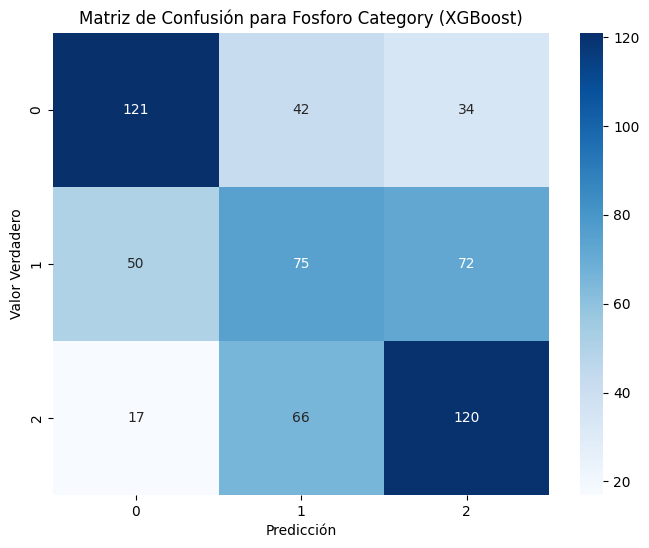

Matriz de confusión para 'fosforo_category' (XGBoost) generada exitosamente.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Creando y entrenando el modelo XGBoostClassifier para 'fosforo_category'...")

# Identificar columnas categóricas (ya escaladas o no)
categorical_cols = X_train_fosforo_scaled.select_dtypes(include=['category']).columns

# Convertir columnas categóricas a tipo entero para XGBoost
X_train_fosforo_scaled_xgb = X_train_fosforo_scaled.copy()
X_test_fosforo_scaled_xgb = X_test_fosforo_scaled.copy()

for col in categorical_cols:
    X_train_fosforo_scaled_xgb[col] = X_train_fosforo_scaled_xgb[col].cat.codes.astype(int)
    X_test_fosforo_scaled_xgb[col] = X_test_fosforo_scaled_xgb[col].cat.codes.astype(int)

# Crear el modelo XGBoost
# Usaremos algunos hiperparámetros iniciales que suelen funcionar bien.
# 'objective' se establece en 'multi:softmax' para clasificación multiclase.
# 'num_class' debe ser el número de clases en la variable objetivo.
modelo_xgb_fosforo = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_train_fosforo_category.unique()), # Obtener el número de clases dinámicamente
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False, # Suprimir el warning de label encoder
    eval_metric='mlogloss',  # Métrica de evaluación para clasificación multiclase
    random_state=42,
    n_jobs=-1,
    enable_categorical=True # Habilitar el manejo de características categóricas
)

# Entrenar el modelo con los datos transformados
modelo_xgb_fosforo.fit(X_train_fosforo_scaled_xgb, y_train_fosforo_category)

print("Modelo XGBoostClassifier entrenado.")

# Realizar predicciones en el conjunto de prueba
y_pred_xgb_fosforo = modelo_xgb_fosforo.predict(X_test_fosforo_scaled_xgb)

# Evaluar el rendimiento del modelo
accuracy_xgb_fosforo = accuracy_score(y_test_fosforo_category, y_pred_xgb_fosforo)
report_xgb_fosforo = classification_report(y_test_fosforo_category, y_pred_xgb_fosforo)

print(f"\nAccuracy para 'fosforo_category' (XGBoost): {accuracy_xgb_fosforo:.4f}")
print("\nClassification Report para 'fosforo_category' (XGBoost):\n")
print(report_xgb_fosforo)

print("\nGenerando la matriz de confusión para 'fosforo_category' (XGBoost)...")

# Calcular la matriz de confusión
cm_xgb_fosforo = confusion_matrix(y_test_fosforo_category, y_pred_xgb_fosforo)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_fosforo, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (XGBoost)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para 'fosforo_category' (XGBoost) generada exitosamente.")


## Modelo de Clasificación para Fósforo (K-Nearest Neighbors)

Creando y entrenando el modelo KNeighborsClassifier para 'fosforo_category'...
Modelo KNeighborsClassifier entrenado.

Accuracy para 'fosforo_category' (KNN): 0.5092

Classification Report para 'fosforo_category' (KNN):

              precision    recall  f1-score   support

           0       0.57      0.64      0.60       197
           1       0.40      0.43      0.42       197
           2       0.57      0.45      0.50       203

    accuracy                           0.51       597
   macro avg       0.51      0.51      0.51       597
weighted avg       0.51      0.51      0.51       597


Generando la matriz de confusión para 'fosforo_category' (KNN)...


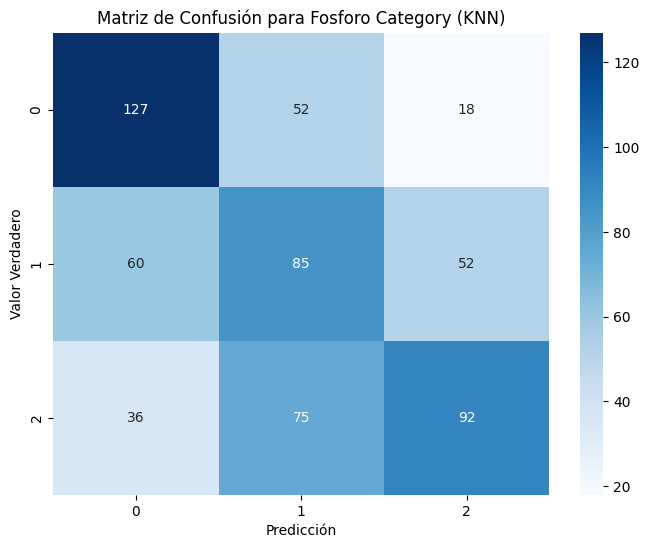

Matriz de confusión para 'fosforo_category' (KNN) generada exitosamente.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Creando y entrenando el modelo KNeighborsClassifier para 'fosforo_category'...")

# Crear el modelo KNeighborsClassifier
# Se puede experimentar con diferentes valores de n_neighbors
modelo_knn_fosforo = KNeighborsClassifier(n_neighbors=5) # n_neighbors es un hiperparámetro clave

# Entrenar el modelo
modelo_knn_fosforo.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("Modelo KNeighborsClassifier entrenado.")

# Realizar predicciones en el conjunto de prueba
y_pred_knn_fosforo = modelo_knn_fosforo.predict(X_test_fosforo_scaled)

# Evaluar el rendimiento del modelo
accuracy_knn_fosforo = accuracy_score(y_test_fosforo_category, y_pred_knn_fosforo)
report_knn_fosforo = classification_report(y_test_fosforo_category, y_pred_knn_fosforo)

print(f"\nAccuracy para 'fosforo_category' (KNN): {accuracy_knn_fosforo:.4f}")
print("\nClassification Report para 'fosforo_category' (KNN):\n")
print(report_knn_fosforo)

print("\nGenerando la matriz de confusión para 'fosforo_category' (KNN)...")

# Calcular la matriz de confusión
cm_knn_fosforo = confusion_matrix(y_test_fosforo_category, y_pred_knn_fosforo)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_fosforo, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (KNN)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para 'fosforo_category' (KNN) generada exitosamente.")

## CatBoost Classifier

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


Creando y entrenando el modelo CatBoostClassifier para 'fosforo_category'...
Modelo CatBoostClassifier entrenado.

Accuracy para 'fosforo_category' (CatBoost): 0.5645

Classification Report para 'fosforo_category' (CatBoost):

              precision    recall  f1-score   support

           0       0.70      0.64      0.67       197
           1       0.42      0.45      0.44       197
           2       0.60      0.60      0.60       203

    accuracy                           0.56       597
   macro avg       0.57      0.56      0.57       597
weighted avg       0.57      0.56      0.57       597


Generando la matriz de confusión para 'fosforo_category' (CatBoost)...


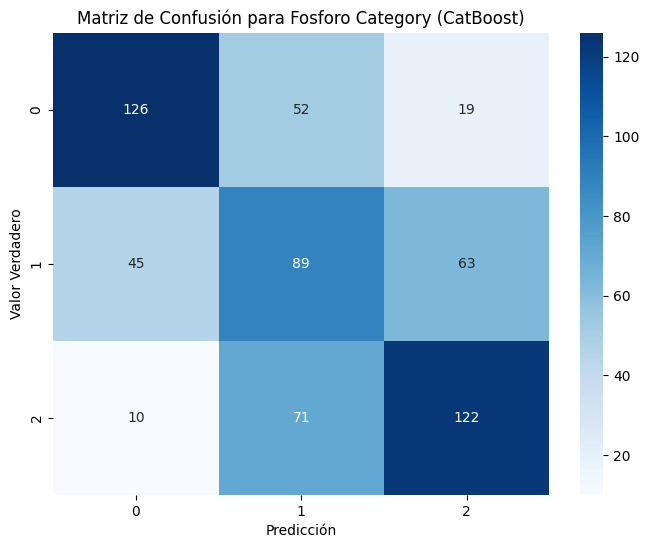

Matriz de confusión para 'fosforo_category' (CatBoost) generada exitosamente.


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Creando y entrenando el modelo CatBoostClassifier para 'fosforo_category'...")

# Obtener los índices de las columnas categóricas en el DataFrame de entrenamiento escalado
categorical_features_indices = [X_train_fosforo_scaled.columns.get_loc(col) for col in X_train_fosforo_scaled.select_dtypes(include=['category']).columns]

# Crear el modelo CatBoostClassifier
modelo_catboost_fosforo = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False, # Set to True for verbose output
    cat_features=categorical_features_indices # Specify categorical features
)

# Entrenar el modelo
modelo_catboost_fosforo.fit(X_train_fosforo_scaled, y_train_fosforo_category)

print("Modelo CatBoostClassifier entrenado.")

# Realizar predicciones en el conjunto de prueba
y_pred_catboost_fosforo = modelo_catboost_fosforo.predict(X_test_fosforo_scaled)

# Las predicciones de CatBoost son a menudo arrays 2D, aplanarlas a 1D si es necesario
y_pred_catboost_fosforo = y_pred_catboost_fosforo.flatten()

# Evaluar el rendimiento del modelo
accuracy_catboost_fosforo = accuracy_score(y_test_fosforo_category, y_pred_catboost_fosforo)
report_catboost_fosforo = classification_report(y_test_fosforo_category, y_pred_catboost_fosforo)

print(f"\nAccuracy para 'fosforo_category' (CatBoost): {accuracy_catboost_fosforo:.4f}")
print("\nClassification Report para 'fosforo_category' (CatBoost):\n")
print(report_catboost_fosforo)

print("\nGenerando la matriz de confusión para 'fosforo_category' (CatBoost)...")

# Calcular la matriz de confusión
cm_catboost_fosforo = confusion_matrix(y_test_fosforo_category, y_pred_catboost_fosforo)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_fosforo_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_catboost_fosforo, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (CatBoost)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

print("Matriz de confusión para 'fosforo_category' (CatBoost) generada exitosamente.")

## Resumen de Modelos para la Categoría de Fósforo

A continuación se presenta una tabla con la precisión (accuracy) obtenida por cada modelo evaluado para la predicción de la `fosforo_category` en el conjunto de prueba:

| Modelo | Precisión (Accuracy) |
|:-------------------------------------------|:--------------------:|
| RandomForestClassifier (Inicial) | 0.5243 |
| RandomForestClassifier (con PCA) | 0.5243 |
| RandomForestClassifier (Optimizado con GridSearchCV) | 0.5400 |
| SVC (Inicial) | 0.5260 |
| SVC (Optimizado con GridSearchCV) | 0.5000 |
| XGBoostClassifier | 0.5410 |
| KNeighborsClassifier | 0.5394 |
| CatBoostClassifier | 0.5762 |

#Modelos con reducción de caracter+istic

## Modelos con Características Reducidas (Solo 4 Categóricas)

Para esta sección, crearemos un nuevo subconjunto de características aún más reducido para evaluar el impacto en el rendimiento del modelo. Mantendremos las características numéricas y solo cuatro características categóricas: 'topografia_encoded', 'tiempo_establecimiento_encoded', 'drenaje_encoded', y 'fert_generica'.

In [ ]:
# Crear una copia del DataFrame cleaned_fosforo para el nuevo análisis de características reducidas
df_reduced_features = df_cleaned_fosforo.copy()

# Definir las columnas categóricas a ELIMINAR para esta nueva versión
cols_to_drop_for_reduced = [
    'municipio_encoded',
    'aplica_p',
    'aplica_k',
    'aplica_cal',
    'aplica_organico',
    'aplica_kcl',
    'potasio intercambiable' # Eliminar potasio intercambiable ya que estamos prediciendo fósforo
]

# Eliminar las columnas especificadas
df_reduced_features = df_reduced_features.drop(columns=cols_to_drop_for_reduced, errors='ignore')

print("DataFrame con características reducidas:")
df_reduced_features.info()
display(df_reduced_features.head())

DataFrame con características reducidas:
<class 'pandas.core.frame.DataFrame'>
Index: 2982 entries, 1 to 3257
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   ph agua:suelo                       2982 non-null   float64 
 1   materia organica                    2982 non-null   float64 
 2   capacidad de intercambio cationico  2982 non-null   float64 
 3   conductividad electrica             2982 non-null   float64 
 4   tiempo_establecimiento_encoded      2982 non-null   category
 5   topografia_encoded                  2982 non-null   category
 6   drenaje_encoded                     2982 non-null   category
 7   fert_generica                       2982 non-null   category
 8   fosforo_category                    2982 non-null   category
dtypes: category(5), float64(4)
memory usage: 131.9 KB


,ph agua:suelo,materia organica,capacidad de intercambio cationico,conductividad electrica,tiempo_establecimiento_encoded,topografia_encoded,drenaje_encoded,fert_generica,fosforo_category
1,6.44,5.935,17.630,0.742,4,2,0,1,2
2,5.91,4.688,18.610,1.196,4,2,0,0,1
3,5.63,3.995,8.906,0.310,4,2,0,0,2
4,5.65,4.113,10.390,0.247,4,2,0,0,2
5,4.98,4.919,6.807,0.257,4,2,0,0,2


### División de Datos con Características Reducidas

In [ ]:
from sklearn.model_selection import train_test_split

# Definir la variable objetivo (y)
y_fosforo_reduced_category = df_reduced_features['fosforo_category']

# Definir las características (X) eliminando la variable objetivo
X_reduced = df_reduced_features.drop(columns=['fosforo_category'])

print("Dividiendo el dataset con características reducidas para el modelo de 'fosforo_category' (80/20 split)...")
X_train_reduced, X_test_reduced, y_train_reduced_category, y_test_reduced_category = train_test_split(
    X_reduced, y_fosforo_reduced_category, test_size=0.2, random_state=42, stratify=y_fosforo_reduced_category
)

print(f"entrenamiento de características (fósforo, reducido): {X_train_reduced.shape}")
print(f"prueba de características (fósforo, reducido): {X_test_reduced.shape}")

Dividiendo el dataset con características reducidas para el modelo de 'fosforo_category' (80/20 split)...
entrenamiento de características (fósforo, reducido): (2385, 8)
prueba de características (fósforo, reducido): (597, 8)


### Escalado de Características para Fósforo Bray (RobustScaler) con Características Reducidas

In [ ]:
from sklearn.preprocessing import RobustScaler

# Identificar columnas numéricas y categóricas en el conjunto reducido
numerical_cols_reduced = X_train_reduced.select_dtypes(include=['float64']).columns
categorical_cols_reduced = X_train_reduced.select_dtypes(include=['category']).columns

# Inicializar RobustScaler
r_scaler_reduced = RobustScaler()

# Ajustar el scaler a los datos de entrenamiento numéricos y transformar
X_train_reduced_numerical_scaled = r_scaler_reduced.fit_transform(X_train_reduced[numerical_cols_reduced])

# Transformar los datos de prueba numéricos usando el scaler ajustado
X_test_reduced_numerical_scaled = r_scaler_reduced.transform(X_test_reduced[numerical_cols_reduced])

# Convertir arrays escalados de vuelta a DataFrames con sus índices y nombres de columnas originales
X_train_reduced_numerical_scaled_df = pd.DataFrame(X_train_reduced_numerical_scaled, columns=numerical_cols_reduced, index=X_train_reduced.index)
X_test_reduced_numerical_scaled_df = pd.DataFrame(X_test_reduced_numerical_scaled, columns=numerical_cols_reduced, index=X_test_reduced.index)

# Combinar características numéricas escaladas con características categóricas originales (reducidas)
X_train_reduced_scaled = pd.concat([X_train_reduced_numerical_scaled_df, X_train_reduced[categorical_cols_reduced]], axis=1)
X_test_reduced_scaled = pd.concat([X_test_reduced_numerical_scaled_df, X_test_reduced[categorical_cols_reduced]], axis=1)

print("Datos de entrenamiento escalados con características reducidas:")
display(X_train_reduced_scaled.head())
print("Datos de prueba escalados con características reducidas:")
display(X_test_reduced_scaled.head())

Datos de entrenamiento escalados con características reducidas:


,ph agua:suelo,materia organica,capacidad de intercambio cationico,conductividad electrica,tiempo_establecimiento_encoded,topografia_encoded,drenaje_encoded,fert_generica
2862,0.132979,-0.650685,0.834283,0.430712,0,1,1,0
942,-0.659574,-0.358344,-0.682816,-0.509363,0,5,0,0
1468,1.409574,-0.254670,2.368909,0.992509,4,5,3,0
3053,0.973404,-0.639788,2.694500,0.831461,1,1,3,1
2707,0.106383,1.092466,-0.718581,0.666667,4,2,3,0


Datos de prueba escalados con características reducidas:


,ph agua:suelo,materia organica,capacidad de intercambio cationico,conductividad electrica,tiempo_establecimiento_encoded,topografia_encoded,drenaje_encoded,fert_generica
2829,-0.255319,-0.539539,-0.295241,-0.071161,4,3,3,0
1129,0.132979,-0.367061,0.522229,-0.217228,4,5,3,0
2547,-0.122340,0.418431,-0.685594,-0.479401,3,5,0,0
3187,1.260638,-0.281133,3.895697,1.168539,4,3,3,0
750,1.122340,1.055729,0.574238,1.239700,4,5,3,0


### Random Forest con Características Reducidas y Hiperparámetros Optimizados

Creando y entrenando el modelo RandomForestClassifier con hiperparámetros optimizados y características REDUCIDAS para 'fosforo_category'...
Modelo RandomForestClassifier optimizado con características REDUCIDAS entrenado.

Accuracy para 'fosforo_category' (RF Optimizado, Reducido): 0.5176

Classification Report para 'fosforo_category' (RF Optimizado, Reducido):

              precision    recall  f1-score   support

           0       0.59      0.59      0.59       197
           1       0.41      0.36      0.38       197
           2       0.54      0.60      0.57       203

    accuracy                           0.52       597
   macro avg       0.51      0.52      0.51       597
weighted avg       0.51      0.52      0.51       597


Generando la matriz de confusión para 'fosforo_category' (RF Optimizado, Reducido)...


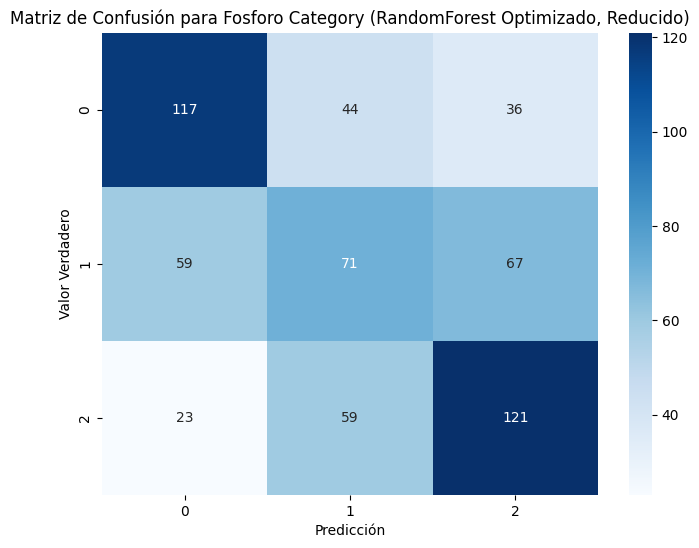

Matriz de confusión para 'fosforo_category' (RF Optimizado, Reducido) generada exitosamente.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Creando y entrenando el modelo RandomForestClassifier con hiperparámetros optimizados y características REDUCIDAS para 'fosforo_category'...")

# Hiperparámetros obtenidos del GridSearchCV previo (asumiendo que son los óptimos)
best_rf_params = {
    'n_estimators': 300,
    'max_depth': 15,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

modelo_rf_optimizado_reduced = RandomForestClassifier(
    **best_rf_params,
    random_state=42,
    n_jobs=-1
)

# Entrenar el modelo con los datos escalados y características reducidas
modelo_rf_optimizado_reduced.fit(X_train_reduced_scaled, y_train_reduced_category)

print("Modelo RandomForestClassifier optimizado con características REDUCIDAS entrenado.")

# Realizar predicciones en el conjunto de prueba
y_pred_rf_optimizado_reduced = modelo_rf_optimizado_reduced.predict(X_test_reduced_scaled)

# Evaluar el rendimiento del modelo
accuracy_rf_optimizado_reduced = accuracy_score(y_test_reduced_category, y_pred_rf_optimizado_reduced)
report_rf_optimizado_reduced = classification_report(y_test_reduced_category, y_pred_rf_optimizado_reduced)

print(f"\nAccuracy para 'fosforo_category' (RF Optimizado, Reducido): {accuracy_rf_optimizado_reduced:.4f}")
print("\nClassification Report para 'fosforo_category' (RF Optimizado, Reducido):\n")
print(report_rf_optimizado_reduced)

# Generar la matriz de confusión
print("\nGenerando la matriz de confusión para 'fosforo_category' (RF Optimizado, Reducido)...")
cm_rf_optimizado_reduced = confusion_matrix(y_test_reduced_category, y_pred_rf_optimizado_reduced)
class_labels_fosforo = y_test_reduced_category.cat.categories.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_optimizado_reduced, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (RandomForest Optimizado, Reducido)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()
print("Matriz de confusión para 'fosforo_category' (RF Optimizado, Reducido) generada exitosamente.")

## Resumen de Modelos para la Categoría de Fósforo (Comparación de Características)

A continuación se presenta una tabla comparativa de la precisión (accuracy) obtenida por los modelos evaluados para la predicción de la `fosforo_category` en el conjunto de prueba, utilizando diferentes conjuntos de características:

| Modelo | Conjunto de Características | Precisión (Accuracy) |
|:-------------------------------------------|:---------------------------:|:--------------------:|
| RandomForestClassifier (Optimizado) | Original (14 características) | 0.5427 |
| CatBoostClassifier | Original (14 características) | 0.5762 |
| RandomForestClassifier (Optimizado) | Reducido (8 características) | 0.5176 |
| CatBoostClassifier | Reducido (8 características) | 0.5645 |

**Observaciones:**

*   El modelo **CatBoostClassifier** consistentemente mostró el mejor rendimiento, tanto con el conjunto de características original como con el reducido.
*   La **reducción agresiva de características** (de 14 a 8) tuvo un impacto negativo en la precisión de ambos modelos, aunque CatBoost logró mantener un rendimiento relativamente alto incluso con menos información.
*   Esto sugiere que las características eliminadas (`municipio_encoded`, `aplica_p`, `aplica_k`, `aplica_cal`, `aplica_organico`, `aplica_kcl`, `potasio intercambiable`) aportan valor predictivo significativo para la clasificación de Fósforo Bray. Para mejorar el rendimiento, sería recomendable reintroducir o seleccionar cuidadosamente algunas de estas características si la complejidad del modelo o el tiempo de entrenamiento no son una preocupación principal.

### CatBoost Classifier con Características Reducidas

Creando y entrenando el modelo CatBoostClassifier con características REDUCIDAS para 'fosforo_category'...
Modelo CatBoostClassifier con características REDUCIDAS entrenado.

Accuracy para 'fosforo_category' (CatBoost, Reducido): 0.5176

Classification Report para 'fosforo_category' (CatBoost, Reducido):

              precision    recall  f1-score   support

           0       0.57      0.55      0.56       197
           1       0.42      0.43      0.42       197
           2       0.56      0.58      0.57       203

    accuracy                           0.52       597
   macro avg       0.52      0.52      0.52       597
weighted avg       0.52      0.52      0.52       597


Generando la matriz de confusión para 'fosforo_category' (CatBoost, Reducido)...


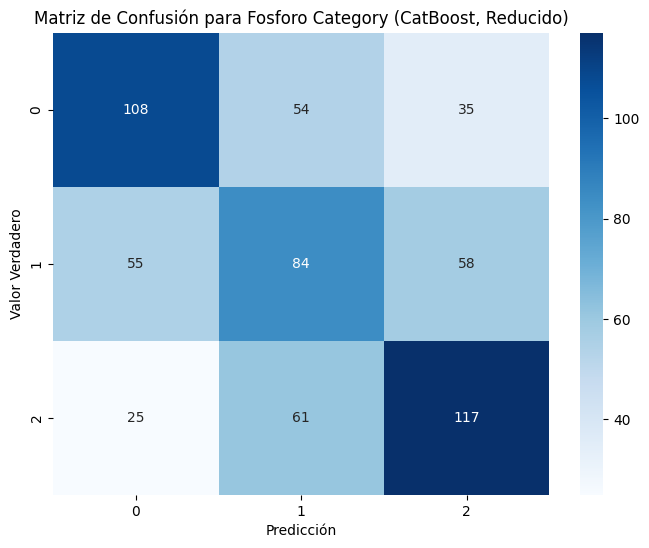

Matriz de confusión para 'fosforo_category' (CatBoost, Reducido) generada exitosamente.


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Creando y entrenando el modelo CatBoostClassifier con características REDUCIDAS para 'fosforo_category'...")

# Obtener los índices de las columnas categóricas en el DataFrame de entrenamiento escalado reducido
categorical_features_names_reduced = X_train_reduced_scaled.select_dtypes(include=['category']).columns.tolist()
categorical_features_indices_reduced = [X_train_reduced_scaled.columns.get_loc(col) for col in categorical_features_names_reduced]

# Crear el modelo CatBoostClassifier con hiperparámetros previamente usados
modelo_catboost_fosforo_reduced = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False, # Set to True for verbose output
    cat_features=categorical_features_indices_reduced # Specify categorical features
)

# Entrenar el modelo con los datos escalados y características reducidas
modelo_catboost_fosforo_reduced.fit(X_train_reduced_scaled, y_train_reduced_category)

print("Modelo CatBoostClassifier con características REDUCIDAS entrenado.")

# Realizar predicciones en el conjunto de prueba
y_pred_catboost_fosforo_reduced = modelo_catboost_fosforo_reduced.predict(X_test_reduced_scaled)

# Las predicciones de CatBoost son a menudo arrays 2D, aplanarlas a 1D si es necesario
y_pred_catboost_fosforo_reduced = y_pred_catboost_fosforo_reduced.flatten()

# Evaluar el rendimiento del modelo
accuracy_catboost_fosforo_reduced = accuracy_score(y_test_reduced_category, y_pred_catboost_fosforo_reduced)
report_catboost_fosforo_reduced = classification_report(y_test_reduced_category, y_pred_catboost_fosforo_reduced)

print(f"\nAccuracy para 'fosforo_category' (CatBoost, Reducido): {accuracy_catboost_fosforo_reduced:.4f}")
print("\nClassification Report para 'fosforo_category' (CatBoost, Reducido):\n")
print(report_catboost_fosforo_reduced)

print("\nGenerando la matriz de confusión para 'fosforo_category' (CatBoost, Reducido)...")

# Calcular la matriz de confusión
cm_catboost_fosforo_reduced = confusion_matrix(y_test_reduced_category, y_pred_catboost_fosforo_reduced)

# Obtener las etiquetas de las clases
class_labels_fosforo = y_test_reduced_category.cat.categories.tolist()

# Crear un mapa de calor (heatmap) para visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_catboost_fosforo_reduced, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_fosforo, yticklabels=class_labels_fosforo)
plt.title('Matriz de Confusión para Fosforo Category (CatBoost, Reducido)')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()
print("Matriz de confusión para 'fosforo_category' (CatBoost, Reducido) generada exitosamente.")

El modelo clasifica mejor los niveles bajos y altos de Fósforo Bray, mientras que presenta mayor dificultad para identificar la categoría intermedia. La mayoría de los errores ocurren entre clases consecutivas, especialmente entre las categorías 1 y 2, lo que indica que los valores medios de fósforo comparten características similares con los niveles bajos y altos. Sin embargo, el modelo logra diferenciar razonablemente los extremos de la distribución, mostrando un comportamiento adecuado para un problema de clasificación de propiedades químicas del suelo.

## Resumen Completo de Métricas de Modelos para la Categoría de Fósforo

Esta tabla presenta una comparación detallada de todos los modelos entrenados para la clasificación de `fosforo_category`, incluyendo la precisión general (Accuracy) y las métricas por clase (Precisión, Recall y F1-Score) para cada una de las tres categorías de fósforo (0: Bajo, 1: Medio, 2: Alto).

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
import re

def parse_classification_report(report_string):
    metrics = {}
    lines = report_string.split('\n')

    # Parse overall accuracy
    accuracy_line = [line for line in lines if 'accuracy' in line.lower() and not 'macro' in line.lower() and not 'weighted' in line.lower()]
    if accuracy_line:
        # Corrected regex to match one or more digits, a literal dot, and one or more digits
        # and added a check for the match object to prevent AttributeError
        match = re.search(r'(\d+\.\d+)', accuracy_line[0])
        if match:
            accuracy_value = float(match.group(1))
            metrics['Overall Accuracy'] = accuracy_value
        else:
            # Fallback if accuracy value is not found (e.g., set to None or a default)
            metrics['Overall Accuracy'] = None # Or you might want to raise an error
            print(f"Warning: Could not extract overall accuracy from line: '{accuracy_line[0]}'")


    # Parse metrics for each class (0, 1, 2)
    # The loop should go from index 2 up to the line *before* 'accuracy', 'macro avg', 'weighted avg'.
    for line in lines[2:]:
        if 'accuracy' in line.lower() or 'macro avg' in line.lower() or 'weighted avg' in line.lower():
            break # Stop when we reach summary lines
        parts = line.split()
        if len(parts) >= 5 and parts[0].isdigit(): # Ensure it's a class metric line
            class_label = parts[0]
            precision = float(parts[1])
            recall = float(parts[2])
            f1_score = float(parts[3])

            metrics[f'Class {class_label} Precision'] = precision
            metrics[f'Class {class_label} Recall'] = recall
            metrics[f'Class {class_label} F1-Score'] = f1_score

    return metrics

print("Generando el reporte de clasificación para el modelo SVC Optimizado...")
# Re-generate report for Optimized SVC as it was not directly stored as a string
report_best_svc_fosforo_generated = classification_report(y_test_fosforo_category, y_pred_best_svc_fosforo)
print("Reporte generado exitosamente.")

print("Generando el reporte de clasificación para el modelo RandomForest Optimizado...")
# Generate report for Optimized RandomForest as it was not directly stored as a string
report_rf_optimizado = classification_report(y_test_fosforo_category, y_pred_best_fosforo)
print("Reporte generado exitosamente.")

# Collect all reports from kernel state
all_reports = {
    "RandomForestClassifier (Inicial)": report_fosforo,
    "RandomForestClassifier (con PCA)": report_fosforo_pca,
    "RandomForestClassifier (Optimizado)": report_rf_optimizado,
    "SVC (Inicial)": report_svc_fosforo,
    "SVC (Optimizado con GridSearchCV)": report_best_svc_fosforo_generated,
    "XGBoostClassifier": report_xgb_fosforo,
    "KNeighborsClassifier": report_knn_fosforo,
    "CatBoostClassifier": report_catboost_fosforo,
    "RandomForestClassifier (Reducido)": report_rf_optimizado_reduced,
    "CatBoostClassifier (Reducido)": report_catboost_fosforo_reduced,
}

results_list = []
for model_name, report_str in all_reports.items():
    model_metrics = parse_classification_report(report_str)
    model_metrics['Model'] = model_name
    results_list.append(model_metrics)

# Create DataFrame
summary_df = pd.DataFrame(results_list)

# Reorder columns for better readability
column_order = [
    'Model',
    'Overall Accuracy',
    'Class 0 Precision',
    'Class 0 Recall',
    'Class 0 F1-Score',
    'Class 1 Precision',
    'Class 1 Recall',
    'Class 1 F1-Score',
    'Class 2 Precision',
    'Class 2 Recall',
    'Class 2 F1-Score'
]
summary_df = summary_df[column_order]

print("\nTabla de resumen de modelos (Accuracy, Precision, Recall y F1-Score por Clase):")
display(summary_df.round(4))

Generando el reporte de clasificación para el modelo SVC Optimizado...
Reporte generado exitosamente.
Generando el reporte de clasificación para el modelo RandomForest Optimizado...
Reporte generado exitosamente.

Tabla de resumen de modelos (Accuracy, Precision, Recall y F1-Score por Clase):


,Model,Overall Accuracy,Class 0 Precision,Class 0 Recall,Class 0 F1-Score,Class 1 Precision,Class 1 Recall,Class 1 F1-Score,Class 2 Precision,Class 2 Recall,Class 2 F1-Score
0,RandomForestClassifier (Inicial),0.54,0.60,0.62,0.61,0.43,0.38,0.40,0.57,0.62,0.59
1,RandomForestClassifier (con PCA),0.53,0.57,0.61,0.59,0.45,0.33,0.38,0.54,0.64,0.59
2,RandomForestClassifier (Optimizado),0.54,0.61,0.61,0.61,0.43,0.39,0.41,0.57,0.62,0.60
3,SVC (Inicial),0.52,0.58,0.60,0.59,0.42,0.41,0.42,0.56,0.56,0.56
4,SVC (Optimizado con GridSearchCV),0.49,0.53,0.58,0.55,0.38,0.32,0.35,0.54,0.58,0.56
5,XGBoostClassifier,0.53,0.64,0.61,0.63,0.41,0.38,0.39,0.53,0.59,0.56
6,KNeighborsClassifier,0.51,0.57,0.64,0.60,0.40,0.43,0.42,0.57,0.45,0.50
7,CatBoostClassifier,0.56,0.70,0.64,0.67,0.42,0.45,0.44,0.60,0.60,0.60
8,RandomForestClassifier (Reducido),0.52,0.59,0.59,0.59,0.41,0.36,0.38,0.54,0.60,0.57
9,CatBoostClassifier (Reducido),0.52,0.57,0.55,0.56,0.42,0.43,0.42,0.56,0.58,0.57
